In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import numpy as np

In [2]:
#1 memuat dataset

df = pd.read_csv('new-thyroid.csv')

In [3]:
df.head()

,107,10.1,2.2,0.9,2.7,1
0,113,9.9,3.1,2.0,5.9,1
1,127,12.9,2.4,1.4,0.6,1
2,109,5.3,1.6,1.4,1.5,1
3,105,7.3,1.5,1.5,-0.1,1
4,105,6.1,2.1,1.4,7.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   107     214 non-null    int64  
 1   10.1    214 non-null    float64
 2   2.2     214 non-null    float64
 3   0.9     214 non-null    float64
 4   2.7     214 non-null    float64
 5   1       214 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 10.2 KB


In [5]:
# 2. Pra-pemrosesan Data
X = df.iloc[:, 1:5]
y_true = df.iloc[:, 5]

In [6]:
# Lakukan penskalaan pada fitur agar setiap fitur memiliki bobot yang sama.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# 3. Menentukan Jumlah Cluster Optimal (Metode Elbow)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_elbow.fit(X_scaled)
    inertia.append(kmeans_elbow.inertia_)

Plot Elbow Method


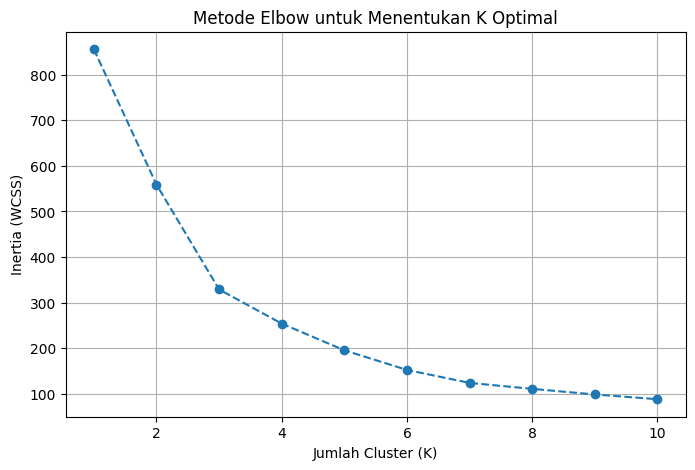

In [8]:
# Membuat plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Metode Elbow untuk Menentukan K Optimal')
plt.grid(True)
plt.savefig('elbow_plot.png')
print("Plot Elbow Method")


In [9]:
# 4. Menerapkan K-Means Clustering
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

Plot visualisasi clustering telah disimpan sebagai 'kmeans_clustering.png'


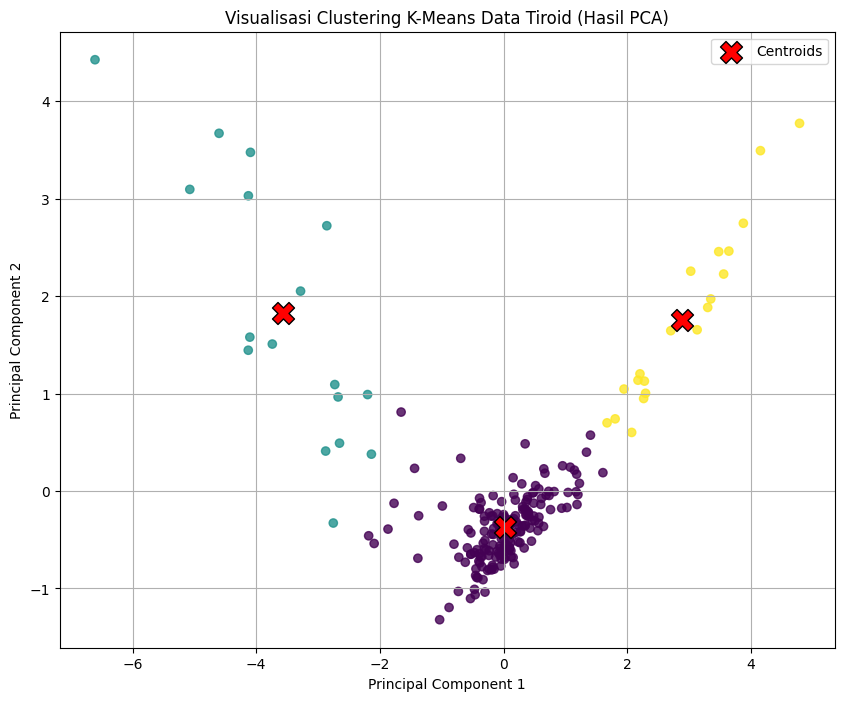

In [10]:
# 5. Visualisasi Hasil Clustering
# Gunakan PCA untuk mereduksi dimensi menjadi 2D untuk visualisasi.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
# Scatter plot untuk data points
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', marker='o', alpha=0.8)

# Menambahkan centroids ke plot
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, marker='X', c='red', edgecolor='black', label='Centroids')

plt.title('Visualisasi Clustering K-Means Data Tiroid (Hasil PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.savefig('kmeans_clustering.png')
print("Plot visualisasi clustering telah disimpan sebagai 'kmeans_clustering.png'")


In [11]:
# 6. Menghitung Varians (Inertia / WCSS)
wcss = kmeans.inertia_
print(f"\nWithin-Cluster Sum of Squares (WCSS) / Inertia: {wcss:.2f}")



Within-Cluster Sum of Squares (WCSS) / Inertia: 328.98


In [12]:
# 7. Menghitung Rasio Kesalahan
df_result = pd.DataFrame({'cluster': cluster_labels, 'true_label': y_true})
contingency_matrix = pd.crosstab(df_result['cluster'], df_result['true_label'])
print("\nContingency Matrix (Cluster vs. Label Asli):")
print(contingency_matrix)

# Temukan label asli yang paling umum untuk setiap cluster.
mapping = contingency_matrix.idxmax(axis=1)
print("\nPemetaan dari cluster ke label asli:")
print(mapping)


# Terapkan pemetaan untuk mendapatkan label yang diprediksi.
predicted_labels = pd.Series(cluster_labels).map(mapping)

# Hitung akurasi dan rasio kesalahan.
accuracy = accuracy_score(y_true, predicted_labels)
error_ratio = 1 - accuracy

print(f"\nAkurasi setelah pemetaan: {accuracy:.4f}")
print(f"Rasio Kesalahan (Error Ratio): {error_ratio:.4f}")



Contingency Matrix (Cluster vs. Label Asli):
true_label    1   2   3
cluster                
0           149  15  13
1             0   0  17
2             0  20   0

Pemetaan dari cluster ke label asli:
cluster
0    1
1    3
2    2
dtype: int64

Akurasi setelah pemetaan: 0.8692
Rasio Kesalahan (Error Ratio): 0.1308
